## Import all Required libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## import dataset

In [3]:
df=pd.read_csv(r"C:\Users\ABHISHEK CHAUHAN\Downloads\india_cancer_patients_2022_2025.csv")
df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


## Summary of data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


In [5]:
df.describe()

,Age,Survival_Months
count,100000.000000,100000.000000
mean,53.899460,20.333353
std,13.653781,14.156450
min,1.000000,1.000000
25%,45.000000,8.200000
50%,54.000000,17.200000
75%,63.000000,30.600000
max,95.000000,53.300000


In [6]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Drop unwanted columns


In [8]:
df.drop(columns=['City','Hospital_Name'],inplace=True,errors='ignore')
df.head()

,Patient_ID,Age,Gender,State,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


## Data Analysis And Visulization

#### Age Group Of Patients

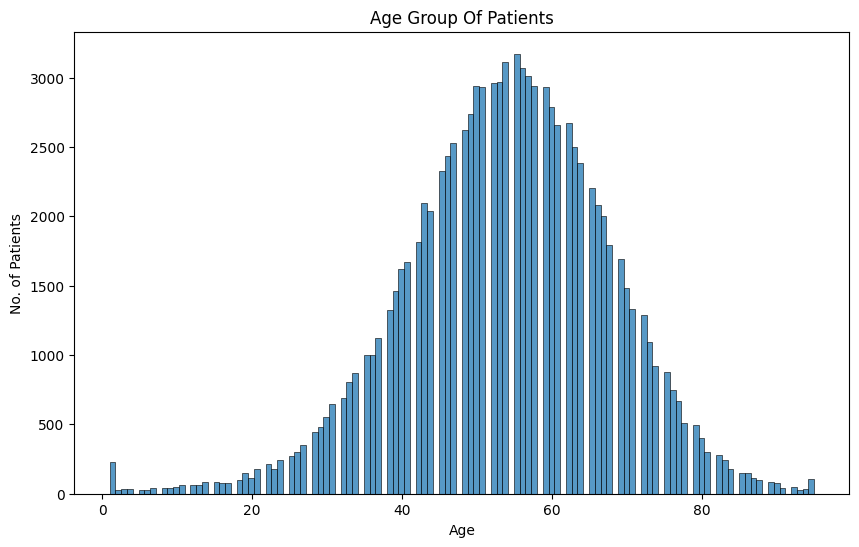

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'])
plt.title("Age Group Of Patients")
plt.ylabel("No. of Patients")
plt.show()

### Recommandations
#### Most of Patients Belong to 40 to 70 age Group .
#### Reason--> Weak immune system and no focus on Health.

### Age wise survival Rate

In [10]:
age=pd.pivot_table(data=df,index='Age',values='Survival_Months',aggfunc='mean',observed=True)
age.reset_index()

,Age,Survival_Months
0,1,19.506987
1,2,19.996296
2,3,21.684375
3,4,23.475000
4,5,22.234615
...,...,...
90,91,18.855814
91,92,21.575556
92,93,19.561538
93,94,22.294444


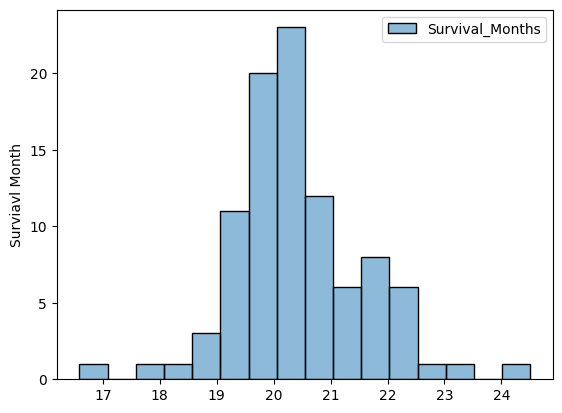

In [11]:
sns.histplot(age)
plt.ylabel("Surviavl Month")
plt.show()

### Recommenadtion
#### Surival Month in  19-20 age group is higher . Due Better Immuune system .
#### Terget Patients--> 1. Rest 0 to 18 Age , 24 Age onwords.


### Geographical Analysis

In [12]:
city=pd.pivot_table(data=df,index=['State'],values='Patient_ID',aggfunc='count',observed=True)
city.reset_index(inplace=True)
city.sort_values(by='Patient_ID',inplace=True)
city

,State,Patient_ID
8,West Bengal,9820
7,Telangana,9885
5,Maharashtra,9954
6,Tamil Nadu,9997
4,Kerala,10030
2,Gujarat,10105
0,Chandigarh,10108
3,Karnataka,10163
1,Delhi,19938


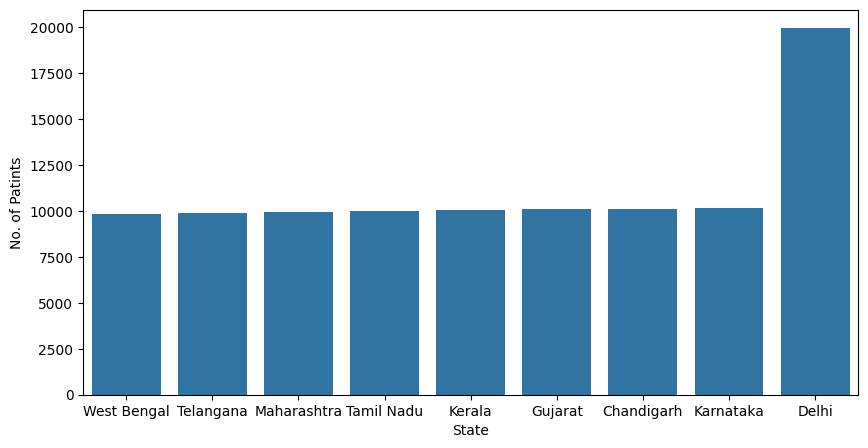

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(data=city,
            x='State',
            y='Patient_ID')
plt.ylabel("No. of Patints")
plt.show()

#### Delhi has the highest patient count (19,938).
#### Reason--> Pollution and industrilization.
#### Recommendation
##### More oppurtuninty and profit by treating large no. of Patients easy access to medicines due to induatrial support.
#### West Bengal has the lowest patient count (9,820).


In [14]:
city2=pd.pivot_table(data=df,index='State',columns="Cancer_Type",values='Patient_ID',aggfunc='count',observed=True)
city2=city2.reset_index()
city2

Cancer_Type,State,Breast Cancer,Cervical Cancer,Colorectal Cancer,Leukemia,Lung Cancer,Oral Cancer,Ovarian Cancer,Prostate Cancer,Stomach Cancer
0,Chandigarh,2858,1387,795,452,1194,1624,396,563,839
1,Delhi,5647,2787,1583,768,2413,3261,779,1152,1548
2,Gujarat,2816,1429,801,389,1233,1672,419,543,803
3,Karnataka,2855,1447,797,446,1195,1649,382,606,786
4,Kerala,2861,1294,784,400,1247,1638,416,595,795
5,Maharashtra,2841,1393,777,414,1177,1619,403,531,799
6,Tamil Nadu,2787,1379,829,436,1182,1618,390,595,781
7,Telangana,2762,1416,807,366,1247,1546,345,601,795
8,West Bengal,2742,1349,762,399,1158,1632,378,623,777


<Axes: xlabel='State', ylabel='Patient_Count'>

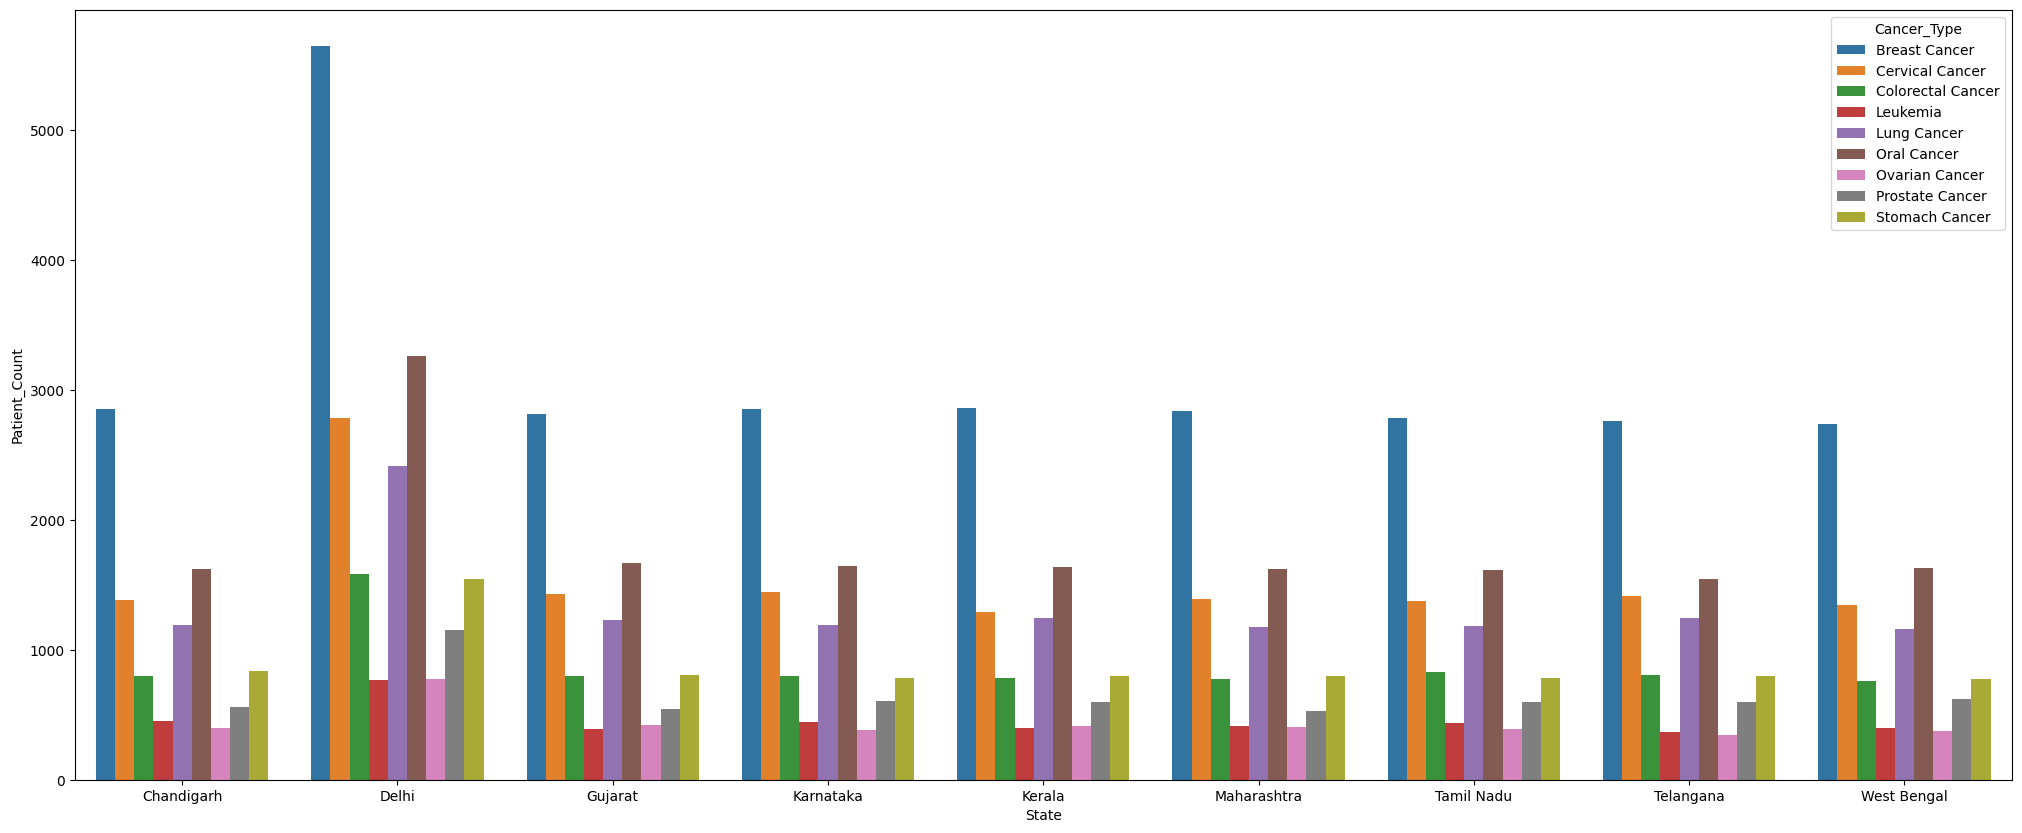

In [15]:
city2_long = city2.melt(
    id_vars='State',
    var_name='Cancer_Type',
    value_name='Patient_Count'
)
plt.figure(figsize=(25,10))
sns.barplot(
    data=city2_long,
    x='State',
    y='Patient_Count',
    hue='Cancer_Type'
)

### Recommendation 
#### Delhi is Top in every Disease
1. Breast Cancer → Delhi (5647) is highest  
2. Cervical Cancer → Delhi (2787) is highest  
3. Colorectal Cancer → Delhi (1583) is highest  
4. Leukemia → Delhi (768) is highest  
5. Lung Cancer → Delhi (2413) is highest  
6. Oral Cancer → Delhi (3261) is highest  
7. Ovarian Cancer → Delhi (779) is highest  
8. Prostate Cancer → Delhi (1152) is highest  
9. Stomach Cancer → Delhi (1548) is highest


#### Gender wise Patients

In [16]:
city3=pd.pivot_table(data=df,index='State',columns="Gender",values='Patient_ID',aggfunc='count',observed=True)
city3.reset_index()

Gender,State,Female,Male
0,Chandigarh,6732,3376
1,Delhi,13447,6491
2,Gujarat,6820,3285
3,Karnataka,6835,3328
4,Kerala,6665,3365
5,Maharashtra,6747,3207
6,Tamil Nadu,6724,3273
7,Telangana,6618,3267
8,West Bengal,6563,3257


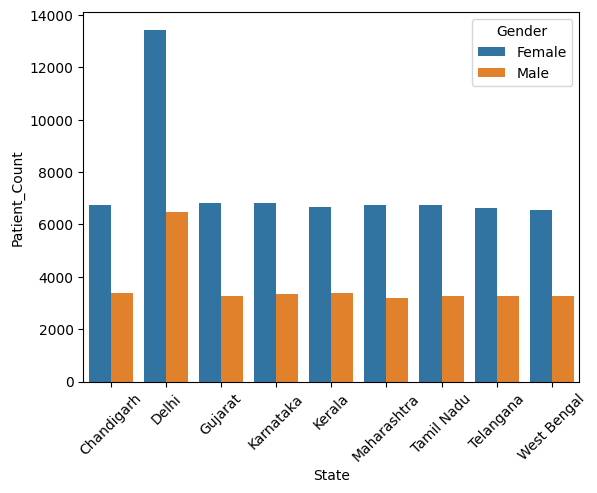

In [17]:

city3 = city3.reset_index()
city3_long = city3.melt(
    id_vars='State',
    var_name='Gender',
    value_name='Patient_Count'
)
sns.barplot(
    data=city3_long,
    x='State',
    y='Patient_Count',
    hue='Gender'
)

plt.xticks(rotation=45)
plt.show()


#### Recommendations
1. Chandigarh → Female (6732) is highest  
2. Delhi → Female (13447) is highest  
3. Gujarat → Female (6820) is highest  
4. Karnataka → Female (6835) is highest  
5. Kerala → Female (6665) is highest  
6. Maharashtra → Female (6747) is highest  
7. Tamil Nadu → Female (6724) is highest  
8. Telangana → Female (6618) is highest  
9. West Bengal → Female (6563) is highest
##### Reason--> No. of female patients in 1.5 times  of male in very State.
##### Main causes:-- 1. lack of awarness.
 2. Work responsibilities of family.
 3. No focous on Gyms and Health
                      



## Survival analysis

### Gender wise

In [18]:
survival1=pd.pivot_table(data=df,index='Gender',values='Survival_Months',aggfunc='mean',observed=True)
survival1=survival1.reset_index()
survival1

,Gender,Survival_Months
0,Female,20.632198
1,Male,19.722445


✅ Key Point
Female patients have a longer average survival (20.63 months).

Male patients have a shorter average survival (19.72 months).

### Type wise

In [19]:
survival2=pd.pivot_table(data=df,index='Cancer_Type',values='Survival_Months',aggfunc='mean',observed=True)
survival2=survival2.reset_index()
survival2

,Cancer_Type,Survival_Months
0,Breast Cancer,21.980258
1,Cervical Cancer,20.177559
2,Colorectal Cancer,19.626881
3,Leukemia,20.111229
4,Lung Cancer,16.753213
5,Oral Cancer,20.888499
6,Ovarian Cancer,20.808316
7,Prostate Cancer,22.613789
8,Stomach Cancer,17.970340


C:\Users\ABHISHEK CHAUHAN\AppData\Local\Temp\ipykernel_25912\2046985501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Survival Months')

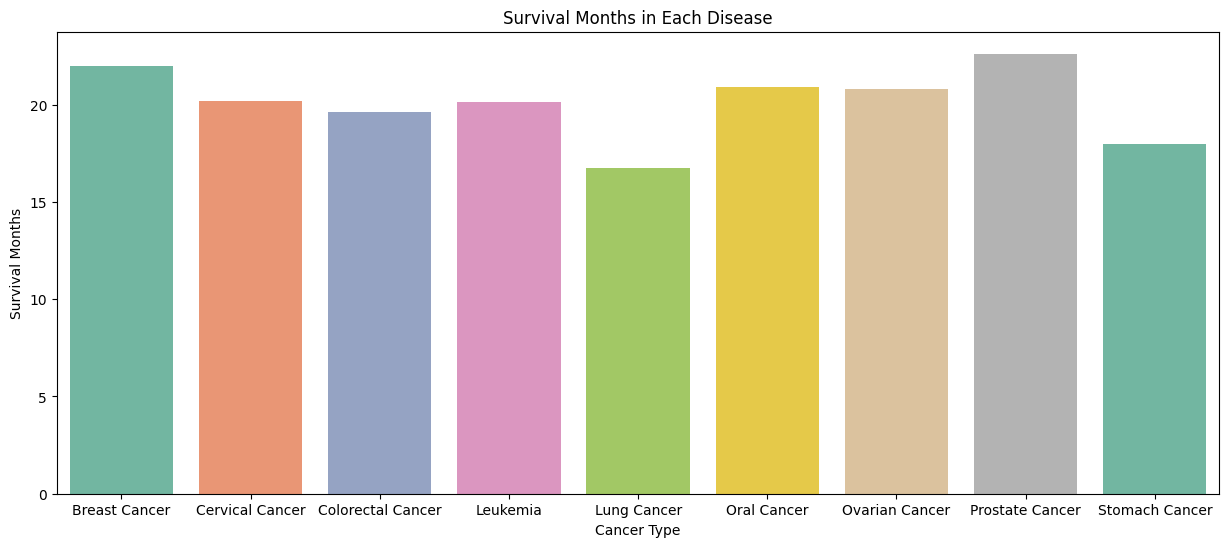

In [20]:
colors = sns.color_palette("Set2", len(survival2))
plt.figure(figsize=(15,6))
sns.barplot(
    data=survival2,
    x='Cancer_Type',
    y='Survival_Months',
    palette=colors  
)

plt.title("Survival Months in Each Disease")
plt.xlabel("Cancer Type")
plt.ylabel("Survival Months")


✅ Key Points
Prostate Cancer (22.61 months) has the highest average survival.

Lung Cancer (16.75 months) has the lowest average survival.

Most other cancers cluster around 20–21 months, showing moderate survival outcomes.

### State wise

In [21]:
survival3=pd.pivot_table(data=df,index='State',values='Survival_Months',aggfunc='mean',observed=True)
survival3=survival3.reset_index()
survival3

,State,Survival_Months
0,Chandigarh,19.977206
1,Delhi,20.429923
2,Gujarat,20.388669
3,Karnataka,20.439614
4,Kerala,20.342144
5,Maharashtra,20.264185
6,Tamil Nadu,20.412384
7,Telangana,20.346839
8,West Bengal,20.304084


✅ Key Points
Karnataka (20.44 months) has the highest average survival.

Chandigarh (19.98 months) has the lowest average survival.

Most states cluster around 20.3–20.4 months, showing relatively small variation.

## Treatment Outcome Studies

In [22]:
df['Treatment_Type'].unique()

array(['Palliative Care', 'Targeted Therapy', 'Surgery + Chemotherapy',
       'Radiation', 'Surgery', 'Chemotherapy', 'Chemo + Radiation'],
      dtype=object)

In [23]:
treatment=pd.pivot_table(data=df,index='Treatment_Type',columns='Status',values='Patient_ID',aggfunc='count',observed=True)
treatment=treatment.reset_index()
treatment

Status,Treatment_Type,Alive,Deceased
0,Chemo + Radiation,3321,5226
1,Chemotherapy,4428,11618
2,Palliative Care,5040,16062
3,Radiation,5231,6387
4,Surgery,11057,9578
5,Surgery + Chemotherapy,3350,5183
6,Targeted Therapy,3996,9523


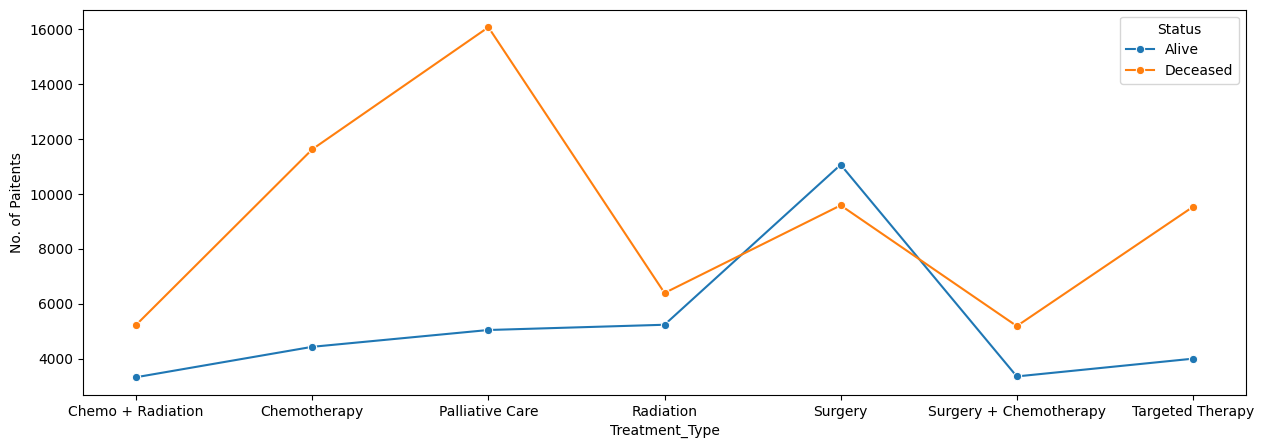

In [24]:
treatment_long = treatment.melt(
    id_vars='Treatment_Type',
    var_name='Status',
    value_name='Patient_Count'
)
plt.figure(figsize=(15,5))
sns.lineplot(
    data=treatment_long,
    x='Treatment_Type',
    y='Patient_Count',
    hue='Status',
marker="o")
plt.ylabel("No. of Paitents")

plt.show()

✨ Strategic takeaway: Surgery remains the cornerstone of treatment, but combining it with radiation or chemo may improve outcomes in specific cancer types. Pure chemo or palliative care alone should not be frontline options when curative intent is possible.

In [25]:
treatment1=pd.pivot_table(data=df,index=['Cancer_Type','Treatment_Type'],
                                         columns='Status',values='Patient_ID',aggfunc='count',observed=True)
treatment1=treatment1.reset_index()
treatment1["Success_Rate"]=(treatment1['Alive']/(treatment1['Alive']+treatment1['Deceased']))*100
best_treatments = treatment1.loc[
    treatment1.groupby("Cancer_Type")["Success_Rate"].idxmax()
]
best_treatments


Status,Cancer_Type,Treatment_Type,Alive,Deceased,Success_Rate
4,Breast Cancer,Surgery,4094,1721,70.404127
11,Cervical Cancer,Surgery,1564,1254,55.500355
18,Colorectal Cancer,Surgery,766,848,47.459727
25,Leukemia,Surgery,422,400,51.338200
32,Lung Cancer,Surgery,459,2011,18.582996
39,Oral Cancer,Surgery,1987,1399,58.682812
46,Ovarian Cancer,Surgery,461,385,54.491726
53,Prostate Cancer,Surgery,908,295,75.477972
60,Stomach Cancer,Surgery,396,1265,23.841060


✅ Recommendations
Prioritize surgery for cancers where success rates are high (Prostate, Breast).

Combine surgery with other therapies (chemo, radiation, targeted therapy) for moderate success cancers (Oral, Ovarian, Cervical, Leukemia).

Avoid surgery as the primary treatment for Lung and Stomach cancers — success rates are very low, so multimodal approaches are essential.

Colorectal cancer shows <50% success with surgery alone → consider adjuvant therapies.

🔹 Strategic Takeaway
Surgery is most beneficial in localized cancers (Breast, Prostate).

For systemic or aggressive cancers (Lung, Stomach), surgery alone is insufficient.

Treatment planning should be cancer-type specific, not one-size-fits-all.

###  PREDICITION MODEL

In [26]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = [
    'Gender',
    'State',
    'Cancer_Type',
    'Stage',
    'Treatment_Type',
    'Status'
]

encoder = OrdinalEncoder()

df[cat_cols] = encoder.fit_transform(df[cat_cols])

df.head()

,Patient_ID,Age,Gender,State,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,0.0,1.0,8.0,2.0,2.0,2024-06-05,3.5,1.0
1,IND-CAN-100001,45,0.0,8.0,1.0,3.0,2.0,2023-08-12,34.0,0.0
2,IND-CAN-100002,47,1.0,0.0,5.0,2.0,6.0,2023-09-09,33.0,0.0
3,IND-CAN-100003,1,0.0,1.0,3.0,1.0,2.0,2024-03-01,27.3,0.0
4,IND-CAN-100004,52,0.0,5.0,1.0,3.0,2.0,2022-05-17,24.0,1.0


In [27]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  float64
 3   State            100000 non-null  float64
 4   Cancer_Type      100000 non-null  float64
 5   Stage            100000 non-null  float64
 6   Treatment_Type   100000 non-null  float64
 7   Diagnosis_Date   100000 non-null  object 
 8   Survival_Months  100000 non-null  float64
 9   Status           100000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 7.6+ MB
None
       Patient_ID  Age  Gender  State  Cancer_Type  Stage  Treatment_Type  \
0  IND-CAN-100000   82     0.0    1.0          8.0    2.0             2.0   
1  IND-CAN-100001   45     0.0    8.0          1.0    3.0             2.0   
2  IND-CAN-100002   47     1

In [28]:
x = df.drop(columns=['Patient_ID','Diagnosis_Date','Status'])
y = df['Status']

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [31]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr=LogisticRegression()

In [40]:
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
lr.score(x_test,y_test)*100

77.125

In [56]:
lr.predict([[32,0.0,1.0,1.0,5.0,3.0,12.0]])

C:\Users\ABHISHEK CHAUHAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1.])

# Cancer Treatment Analysis Project – Summary
## Project Overview

This project analyzes a cancer patient dataset (2022–2025) to identify trends in patient demographics, cancer types, geographical distribution, treatment outcomes, and survival rates. It also builds a machine learning model to predict patient status based on medical and demographic factors.

### Objectives
Understand the distribution of cancer patients across different age groups.
Analyze survival rates among patients.
Identify states with the highest and lowest cancer cases.
Study gender-wise and cancer-type-wise trends.
Discover patterns that can help healthcare organizations improve treatment strategies.
Build a predictive model for patient status prediction.
Data Preparation

#### The project performs:

Data loading using Pandas.
Dataset summary and statistical analysis.
Missing value checking.
Duplicate record checking.
Removal of unnecessary columns such as:
City
Hospital_Name
Key Findings
1. Age Group Analysis
Most cancer patients belong to the 40–70 years age group.
This age range shows the highest concentration of cancer cases.

3Recommendation:

Increase awareness and screening programs for middle-aged and elderly populations.
Promote regular health checkups.
2. Age-wise Survival Analysis
Patients in the 19–20 years age group show the highest average survival months.
Younger patients generally have better recovery potential.

Recommendation:

Special attention should be given to older age groups where survival rates are lower.
Early diagnosis programs can improve outcomes.
3. Geographical Analysis
Delhi has the highest number of cancer patients (~19,938).
West Bengal has the lowest patient count among analyzed states.

Possible Reasons for Delhi's High Cases:

High pollution levels.
Urban lifestyle factors.
Large population density.

### Recommendation:

Expand cancer treatment facilities and awareness programs in Delhi.
Increase screening camps in high-risk regions.
4. Cancer Type Distribution

Delhi records the highest number of cases across major cancer categories:

Breast Cancer
Cervical Cancer
Colorectal Cancer
Leukemia
Lung Cancer
Oral Cancer
Ovarian Cancer
Prostate Cancer
Stomach Cancer

 ### Recommendation:

Allocate more healthcare resources for specialized cancer treatment centers.
Conduct targeted awareness campaigns based on cancer type prevalence.
5. Gender-wise Analysis
Female cancer patients outnumber male patients in most states.
Female patient counts are approximately 1.5 times higher than male patient counts in several regions.

### Possible Reasons:

Breast and cervical cancers contribute significantly to female cases.
Lack of awareness and delayed diagnosis.

### Recommendation:

Strengthen women's health screening programs.
Increase awareness regarding breast and cervical cancer detection.
Data Visualization Used

### The project includes visualizations such as:

Age distribution histograms.
Survival rate analysis charts.
State-wise cancer distribution plots.
Gender-wise patient comparisons.
Cancer-type distribution graphs.
Machine Learning Model
Model Used
Logistic Regression
Steps Performed
Categorical data encoding using Ordinal Encoder.
Feature selection.
Train-test split (80%-20%).
Model training using Logistic Regression.
Model evaluation using accuracy score.
Features Used
Age
Gender
State
Cancer Type
Stage
Treatment Type
Survival Months
Target Variable
Patient Status
Conclusion

The analysis reveals that:

Cancer cases are most common among individuals aged 40–70 years.
Younger patients tend to have better survival outcomes.
Delhi has the highest cancer burden among analyzed states.
Female patients represent a larger proportion of cancer cases.
Logistic Regression can be used to predict patient status and support healthcare decision-making.